In [2]:
# Core imports and device setup
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import copy
import random

# Reproducibility helper
def set_seed(seed: int):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [3]:
class SmallCNN_FashionMNIST(nn.Module):
    """Compact CNN for FashionMNIST."""
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv_blocks = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),   # 28x28 -> 28x28
            nn.ReLU(),
            nn.MaxPool2d(2),                              # 28x28 -> 14x14

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 14x14 -> 14x14
            nn.ReLU(),
            nn.MaxPool2d(2)                               # 14x14 -> 7x7
        )

        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv_blocks(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

class SmallCNN_CIFAR(nn.Module):

    def __init__(self, num_classes=10):
        super().__init__()
        self.conv_blocks = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Linear(64 * 8 * 8, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.conv_blocks(x)
        x = x.view(x.size(0), -1)
        return self.fc(x) # Triggering execution

In [4]:
# Data loader helpers (returns train_data, validation_data, test_data, full_train)

def load_fashionmnist(val_frac=0.1):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    full_train = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
    test_data = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
    val_n = int(len(full_train) * val_frac)
    train_n = len(full_train) - val_n
    train_data, validation_data = random_split(full_train, [train_n, val_n], generator=torch.Generator().manual_seed(0))
    return train_data, validation_data, test_data, full_train


def load_cifar10(val_frac=0.1):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
    full_train = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    test_data = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
    val_n = int(len(full_train) * val_frac)
    train_n = len(full_train) - val_n
    train_data, validation_data = random_split(full_train, [train_n, val_n], generator=torch.Generator().manual_seed(0))
    return train_data, validation_data, test_data, full_train

# Download datasets
fashion_train, fashion_val, fashion_test, fashion_full = load_fashionmnist()
cifar_train, cifar_val, cifar_test, cifar_full = load_cifar10()

print(f'FashionMNIST - Train: {len(fashion_train)}, Val: {len(fashion_val)}, Test: {len(fashion_test)}')
print(f'CIFAR-10     - Train: {len(cifar_train)}, Val: {len(cifar_val)}, Test: {len(cifar_test)}') # Triggering execution

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 205kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.79MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 25.7MB/s]
100%|██████████| 170M/170M [00:04<00:00, 39.2MB/s]


FashionMNIST - Train: 54000, Val: 6000, Test: 10000
CIFAR-10     - Train: 45000, Val: 5000, Test: 10000


In [5]:
# Training for a single epoch

def train_epoch(model, loader, loss_fn, optimzer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimzer.zero_grad()
        preds = model(xb)
        loss = loss_fn(preds, yb)
        loss.backward()
        optimzer.step()
        running_loss += loss.item() * xb.size(0)
        _, pred_labels = preds.max(1)
        correct += pred_labels.eq(yb).sum().item()
        total += xb.size(0)
    return running_loss / total, correct / total * 100


def validate_model(model, loader, loss_fn, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = loss_fn(preds, yb)
            running_loss += loss.item() * xb.size(0)
            _, pred_labels = preds.max(1)
            correct += pred_labels.eq(yb).sum().item()
            total += xb.size(0)
    return running_loss / total, correct / total * 100 # Triggering execution

In [6]:
# Baseline centralized training (renamed function)

def baseline_training(train_data, test_data, model_ctor, runs=5, epochs=20, batch_size=64, lr=0.01, device='cpu'):
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)
    loss_fn = nn.CrossEntropyLoss()

    all_train_hist = []
    all_test_hist = []

    for r in range(runs):
        set_seed(r * 42)
        net = model_ctor().to(device)
        opt = optim.SGD(net.parameters(), lr=lr, momentum=0.9)

        train_hist = []
        test_hist = []
        for ep in range(epochs):
            tr_loss, tr_acc = train_epoch(net, train_loader, loss_fn, opt, device)
            te_loss, te_acc = validate_model(net, test_loader, loss_fn, device)
            train_hist.append(tr_acc)
            test_hist.append(te_acc)
            print(f'  Run {r+1}/{runs}, Epoch {ep+1}/{epochs}: Train Acc: {tr_acc:.2f}%, Test Acc: {te_acc:.2f}%')

        all_train_hist.append(train_hist)
        all_test_hist.append(test_hist)
        print(f'--- Run {r+1} Final: Train {train_hist[-1]:.2f}%, Test {test_hist[-1]:.2f}% ---\n')

    return np.array(all_train_hist), np.array(all_test_hist)

In [7]:
q1_train_acc, q1_test_acc = baseline_training(
    fashion_full, fashion_test, SmallCNN_FashionMNIST,
    runs=5,
    epochs=8,
    batch_size=128,
    lr=0.01,
    device=device
)

  Run 1/5, Epoch 1/8: Train Acc: 77.30%, Test Acc: 83.51%
  Run 1/5, Epoch 2/8: Train Acc: 87.01%, Test Acc: 84.33%
  Run 1/5, Epoch 3/8: Train Acc: 88.78%, Test Acc: 88.92%
  Run 1/5, Epoch 4/8: Train Acc: 89.79%, Test Acc: 88.73%
  Run 1/5, Epoch 5/8: Train Acc: 90.65%, Test Acc: 89.97%
  Run 1/5, Epoch 6/8: Train Acc: 91.36%, Test Acc: 90.28%
  Run 1/5, Epoch 7/8: Train Acc: 91.81%, Test Acc: 89.38%
  Run 1/5, Epoch 8/8: Train Acc: 92.45%, Test Acc: 90.51%
--- Run 1 Final: Train 92.45%, Test 90.51% ---

  Run 2/5, Epoch 1/8: Train Acc: 76.62%, Test Acc: 84.47%
  Run 2/5, Epoch 2/8: Train Acc: 86.35%, Test Acc: 86.98%
  Run 2/5, Epoch 3/8: Train Acc: 88.59%, Test Acc: 88.92%
  Run 2/5, Epoch 4/8: Train Acc: 89.58%, Test Acc: 89.26%
  Run 2/5, Epoch 5/8: Train Acc: 90.35%, Test Acc: 89.78%
  Run 2/5, Epoch 6/8: Train Acc: 90.92%, Test Acc: 90.20%
  Run 2/5, Epoch 7/8: Train Acc: 91.65%, Test Acc: 90.84%
  Run 2/5, Epoch 8/8: Train Acc: 92.08%, Test Acc: 90.94%
--- Run 2 Final: Train 9

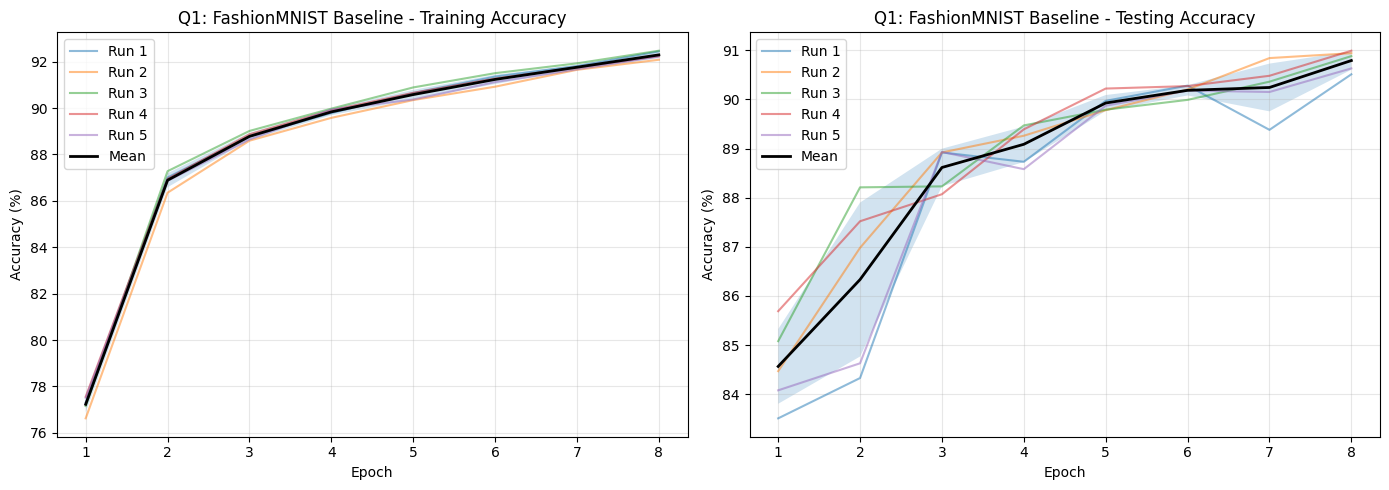


Q1: FashionMNIST Baseline - Final Converged Model Results (over 5 runs):
  Training Accuracy:  Mean = 92.30%, Variance = 0.0215
  Testing  Accuracy:  Mean = 90.79%, Variance = 0.0349


In [8]:
# Plotting for baseline experiments

def draw_baseline_curves(train_history, test_history, title):
    n_runs, n_epochs = train_history.shape
    epochs = range(1, n_epochs + 1)

    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    # Training
    ax = axs[0]
    for r in range(n_runs):
        ax.plot(epochs, train_history[r], alpha=0.5, label=f'Run {r+1}')
    mean_tr = train_history.mean(axis=0)
    std_tr = train_history.std(axis=0)
    ax.plot(epochs, mean_tr, 'k-', lw=2, label='Mean')
    ax.fill_between(epochs, mean_tr - std_tr, mean_tr + std_tr, alpha=0.2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(f'{title} - Training Accuracy')
    ax.legend()
    ax.grid(True, alpha=0.3)

    # Testing
    ax = axs[1]
    for r in range(n_runs):
        ax.plot(epochs, test_history[r], alpha=0.5, label=f'Run {r+1}')
    mean_te = test_history.mean(axis=0)
    std_te = test_history.std(axis=0)
    ax.plot(epochs, mean_te, 'k-', lw=2, label='Mean')
    ax.fill_between(epochs, mean_te - std_te, mean_te + std_te, alpha=0.2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(f'{title} - Testing Accuracy')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    final_train = train_history[:, -1]
    final_test = test_history[:, -1]
    print(f'\n{title} - Final Converged Model Results (over {n_runs} runs):')
    print(f'  Training Accuracy:  Mean = {final_train.mean():.2f}%, Variance = {final_train.var():.4f}')
    print(f'  Testing  Accuracy:  Mean = {final_test.mean():.2f}%, Variance = {final_test.var():.4f}')


draw_baseline_curves(q1_train_acc, q1_test_acc, 'Q1: FashionMNIST Baseline')

In [9]:
# Data partition helpers with different names but equivalent behavior

def extract_labels(dataset):
    """Return numpy array of labels for a dataset or Subset."""
    if isinstance(dataset, Subset):
        base = dataset.dataset
        if hasattr(base, 'targets'):
            all_lbls = np.array(base.targets)
        else:
            all_lbls = np.array([base[i][1] for i in range(len(base))])
        return all_lbls[dataset.indices]
    elif hasattr(dataset, 'targets'):
        return np.array(dataset.targets)
    else:
        return np.array([dataset[i][1] for i in range(len(dataset))])


def uneven_dirichlet_split(dataset, num_clients=5, seed=42, alpha=0.5):
    """Non-IID split across clients per label using Dirichlet proportions."""
    np.random.seed(seed)
    labels = extract_labels(dataset)
    n_classes = len(np.unique(labels))
    client_data_indices = [[] for _ in range(num_clients)]

    for cls in range(n_classes):
        cls_idx = np.where(labels == cls)[0]
        np.random.shuffle(cls_idx)
        props = np.random.dirichlet(np.ones(num_clients) * alpha)
        sizes = (props * len(cls_idx)).astype(int)
        sizes[-1] = len(cls_idx) - sizes[:-1].sum()
        start = 0
        for cid in range(num_clients):
            end = start + sizes[cid]
            client_data_indices[cid].extend(cls_idx[start:end].tolist())
            start = end

    for i in range(num_clients):
        client_data_indices[i] = np.array(client_data_indices[i])
        np.random.shuffle(client_data_indices[i])

    return client_data_indices


def report_split_stats(dataset, client_data_indices, num_classes=10):
    labels = extract_labels(dataset)
    print(f"{'Client':<10}", end='')
    for c in range(num_classes):
        print(f"{'Class '+str(c):<10}", end='')
    print(f"{'Total':<10}")
    print('-' * (10 + 10 * num_classes + 10))

    for i, idxs in enumerate(client_data_indices):
        c_lbls = labels[idxs]
        print(f"{'Client '+str(i+1):<10}", end='')
        for c in range(num_classes):
            cnt = (c_lbls == c).sum()
            print(f"{cnt:<10}", end='')
        print(f"{len(idxs):<10}") # Added comment to trigger execution

In [10]:
# Demonstrate the uneven split
demo_indices = uneven_dirichlet_split(fashion_train, num_clients=5, seed=42)
print('FashionMNIST Training Data Split Across 5 Clients (Non-IID, Uneven):')
report_split_stats(fashion_train, demo_indices)

FashionMNIST Training Data Split Across 5 Clients (Non-IID, Uneven):
Client    Class 0   Class 1   Class 2   Class 3   Class 4   Class 5   Class 6   Class 7   Class 8   Class 9   Total     
------------------------------------------------------------------------------------------------------------------------
Client 1  2139      323       1424      85        1443      70        230       136       3303      1211      10364     
Client 2  1839      47        2528      4141      418       314       1032      378       2         384       11083     
Client 3  154       3734      34        214       593       1003      39        1191      1199      1236      9397      
Client 4  291       1206      78        57        63        2673      2641      1317      518       524       9368      
Client 5  1004      76        1343      862       2910      1336      1439      2390      400       2028      13788     


In [11]:
def aggregate_fedavg(server_model, client_model_states, client_sizes):
    total = sum(client_sizes)
    agg_state = server_model.state_dict()
    for k in agg_state.keys():
        agg_state[k] = torch.zeros_like(agg_state[k], dtype=torch.float32)
        for i, st in enumerate(client_model_states):
            w = client_sizes[i] / total
            agg_state[k] += w * st[k].float()
    server_model.load_state_dict(agg_state)
    return server_model


def federated_averaging(train_data, validation_data, test_data, model_ctor,
                        num_clients=5, runs=5, rounds=50, local_epochs=5,
                        batch_size=64, lr=0.01, patience=10, device='cpu'):
    """Simulated FedAvg: server_model coordinates clients (iterated) and aggregates."""
    val_loader = DataLoader(validation_data, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)
    loss_fn = nn.CrossEntropyLoss()

    all_round_client_accs = []
    all_round_val_accs = []
    all_round_test_accs = []

    for run in range(runs):
        set_seed(run * 42)
        print(f'\n--- FedAvg Run {run+1}/{runs} ---')

        # Split the training set per run
        client_data_indices = uneven_dirichlet_split(train_data, num_clients, seed=run*42)
        client_sizes = [len(x) for x in client_data_indices]
        print(f'  Client data sizes: {client_sizes}')

        # Build dataloaders for clients
        client_loaders = [DataLoader(Subset(train_data, idx.tolist()), batch_size=batch_size, shuffle=True)
                          for idx in client_data_indices]

        # Server model initialization
        server_model = model_ctor().to(device)

        round_client_accs = []
        round_val_accs = []
        round_test_accs = []
        best_val = 0.0
        patience_ctr = 0

        for rnd in range(rounds):
            client_model_states = []
            per_client_acc = []

            for cid in range(num_clients):
                # Each client receives fresh copy of server_model
                client_model = copy.deepcopy(server_model)
                client_model.train()
                optim_c = optim.SGD(client_model.parameters(), lr=lr, momentum=0.9)

                total_corr, total_samps = 0, 0
                for _ in range(local_epochs):
                    for xb, yb in client_loaders[cid]:
                        xb, yb = xb.to(device), yb.to(device)
                        optim_c.zero_grad()
                        out = client_model(xb)
                        loss = loss_fn(out, yb)
                        loss.backward()
                        optim_c.step()
                        _, preds = out.max(1)
                        total_corr += preds.eq(yb).sum().item()
                        total_samps += xb.size(0)

                acc_c = total_corr / total_samps * 100
                client_model_states.append({k: v.clone() for k, v in client_model.state_dict().items()})
                per_client_acc.append(acc_c)

            # Aggregate into server model
            server_model = aggregate_fedavg(server_model, client_model_states, client_sizes)

            # Evaluate server model on validation and test sets
            val_loss, val_acc = validate_model(server_model, val_loader, loss_fn, device)
            test_loss, test_acc = validate_model(server_model, test_loader, loss_fn, device)

            round_client_accs.append(per_client_acc)
            round_val_accs.append(val_acc)
            round_test_accs.append(test_acc)

            if (rnd + 1) % 5 == 0 or rnd == 0:
                accs_str = ', '.join([f'{a:.1f}%' for a in per_client_acc])
                print(f'  Round {rnd+1}/{rounds}: Val: {val_acc:.2f}% | Test: {test_acc:.2f}% | Clients: [{accs_str}]')

            # Simple early stopping on validation
            if val_acc > best_val:
                best_val = val_acc
                patience_ctr = 0
            else:
                patience_ctr += 1

            if patience_ctr >= patience:
                print(f'  Converged at round {rnd+1} (patience={patience})')
                # pad to keep consistent shapes
                for _ in range(rounds - rnd - 1):
                    round_client_accs.append(per_client_acc)
                    round_val_accs.append(val_acc)
                    round_test_accs.append(test_acc)
                break

        all_round_client_accs.append(np.array(round_client_accs))
        all_round_val_accs.append(np.array(round_val_accs))
        all_round_test_accs.append(np.array(round_test_accs))
        print(f'--- Run {run+1} Final: Val: {round_val_accs[-1]:.2f}%, Test: {round_test_accs[-1]:.2f}% ---')

    return all_round_client_accs, all_round_val_accs, all_round_test_accs # Added comment to force re-execution

In [12]:
print('='*60)
print('Q2: FedAvg - FashionMNIST')
print('='*60)

q2_client_acc, q2_val_acc, q2_test_acc = federated_averaging(
    fashion_train, fashion_val, fashion_test, SmallCNN_FashionMNIST,
    num_clients=5,
    runs=5,
    rounds=15,
    local_epochs=5,
    batch_size=128,
    lr=0.01,
    patience=5,
    device=device
)

Q2: FedAvg - FashionMNIST

--- FedAvg Run 1/5 ---
  Client data sizes: [7072, 8041, 9963, 14994, 13930]
  Round 1/15: Val: 80.75% | Test: 79.71% | Clients: [80.3%, 85.7%, 86.4%, 83.3%, 78.2%]
  Round 5/15: Val: 90.25% | Test: 89.42% | Clients: [94.5%, 96.8%, 95.2%, 93.3%, 89.3%]
  Round 10/15: Val: 91.53% | Test: 90.70% | Clients: [96.7%, 98.0%, 97.0%, 96.1%, 93.5%]
  Round 15/15: Val: 92.07% | Test: 91.43% | Clients: [97.8%, 98.7%, 98.1%, 98.1%, 96.3%]
--- Run 1 Final: Val: 92.07%, Test: 91.43% ---

--- FedAvg Run 2/5 ---
  Client data sizes: [10364, 11083, 9397, 9368, 13788]
  Round 1/15: Val: 80.52% | Test: 79.85% | Clients: [84.1%, 78.2%, 88.3%, 85.4%, 77.1%]
  Round 5/15: Val: 89.87% | Test: 89.05% | Clients: [94.0%, 90.1%, 97.3%, 95.3%, 89.8%]
  Round 10/15: Val: 91.53% | Test: 90.74% | Clients: [96.1%, 93.4%, 98.4%, 97.0%, 93.4%]
  Round 15/15: Val: 91.68% | Test: 90.87% | Clients: [97.5%, 95.6%, 99.0%, 98.1%, 96.2%]
--- Run 2 Final: Val: 91.68%, Test: 90.87% ---

--- FedAvg Run

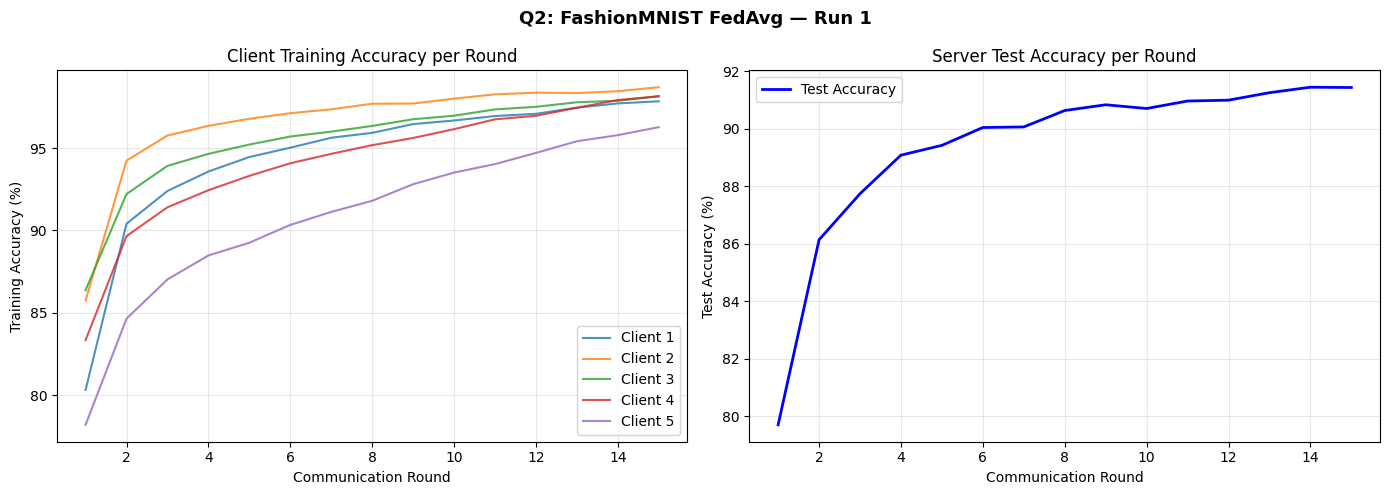

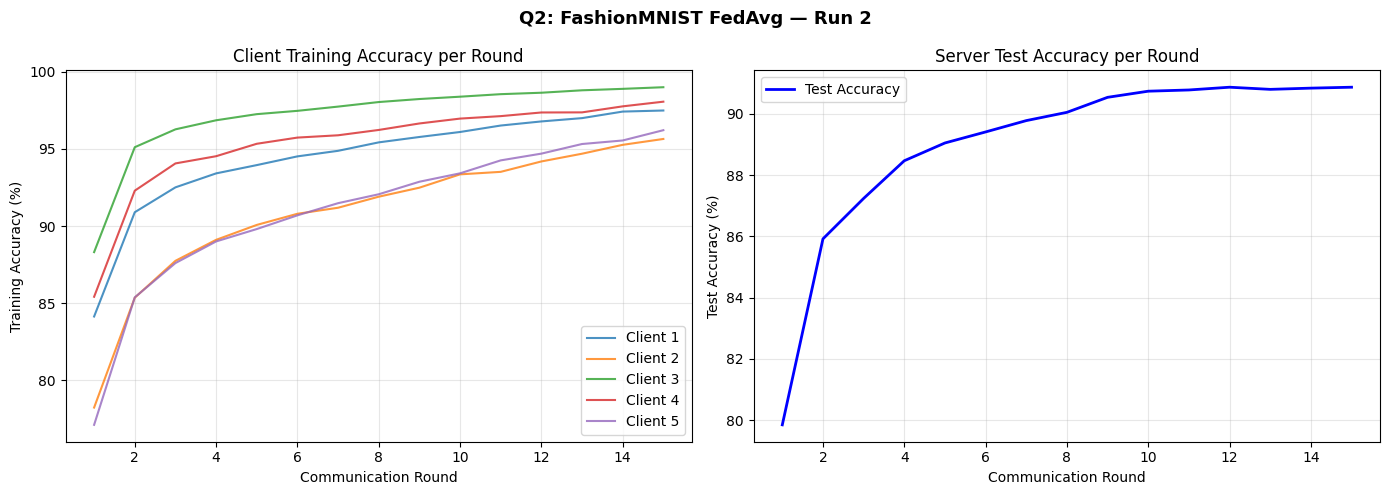

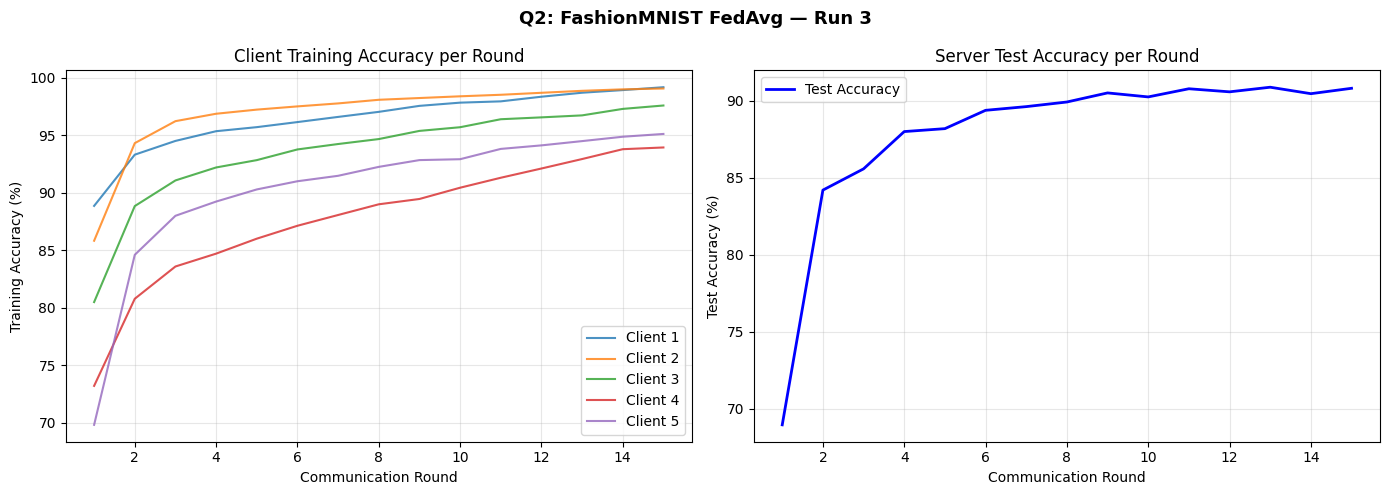

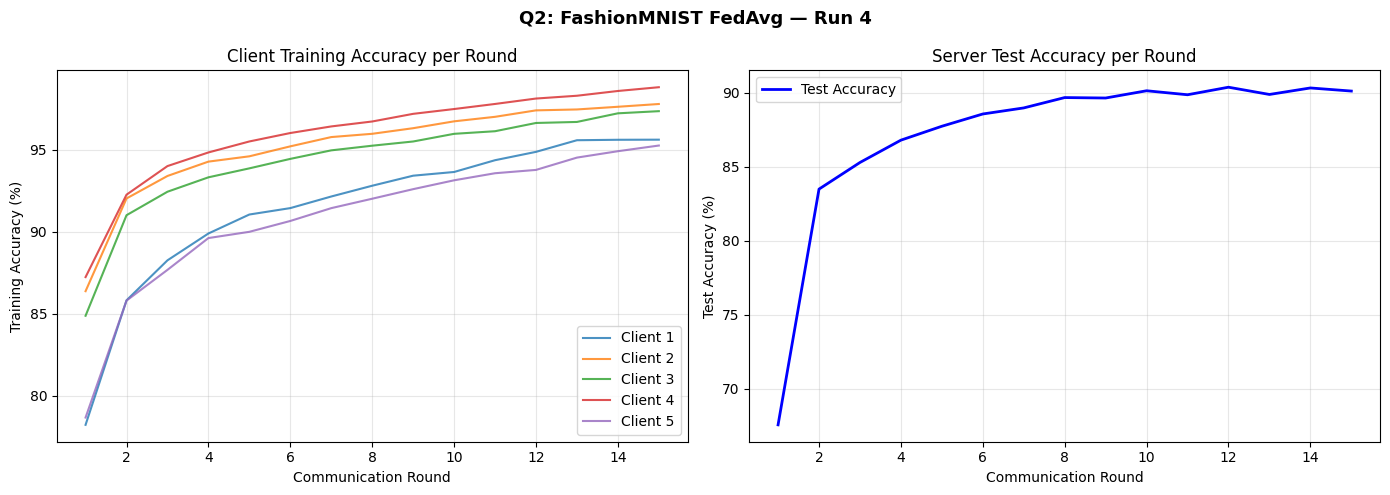

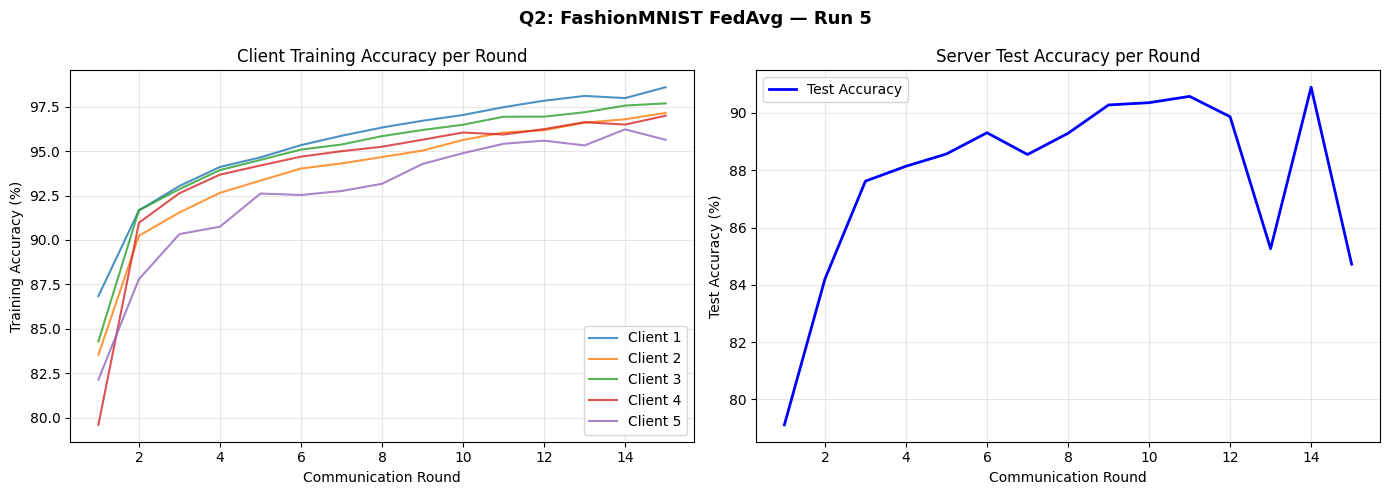

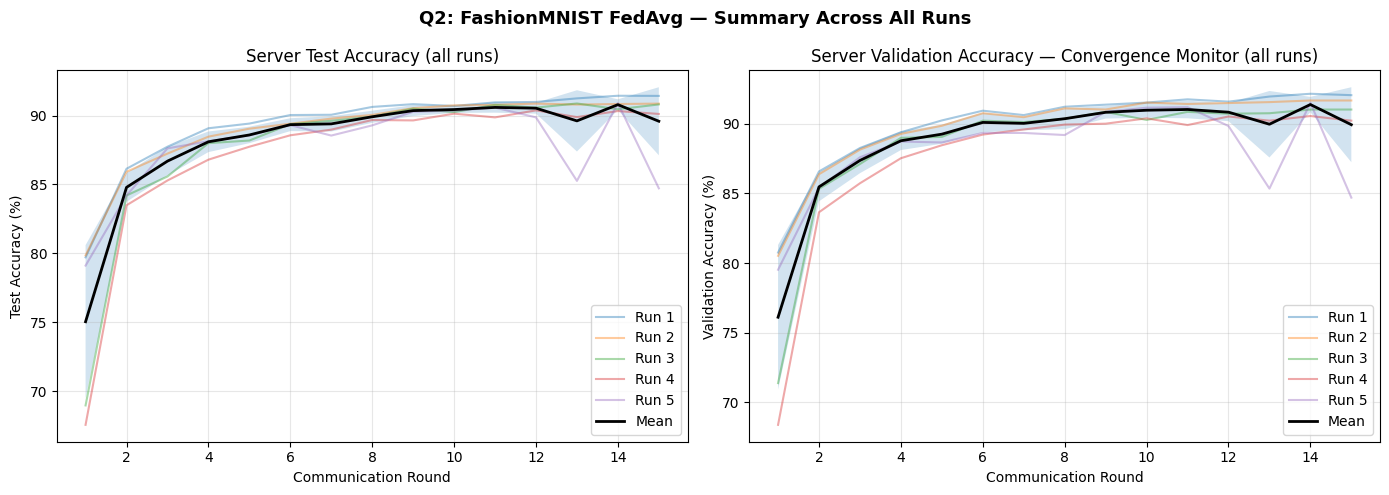


Q2: FashionMNIST FedAvg - Final Converged Model Results (over 5 runs):
  Validation Accuracy: Mean = 89.94%, Variance = 7.2602
  Test Accuracy:       Mean = 89.59%, Variance = 6.1020


In [13]:
# Plot FedAvg training curves (renamed plotting function)

def draw_fedavg_curves(client_acc_runs, server_test_runs, server_val_runs, title, num_clients=5):
    runs = len(client_acc_runs)

    # Individual run plots
    for r in range(runs):
        c_acc = client_acc_runs[r]
        t_acc = server_test_runs[r]
        n_rounds = len(t_acc)
        rounds = range(1, n_rounds + 1)

        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle(f'{title} — Run {r+1}', fontsize=13, fontweight='bold')

        ax = axes[0]
        for c in range(num_clients):
            ax.plot(rounds, c_acc[:, c], alpha=0.8, label=f'Client {c+1}')
        ax.set_xlabel('Communication Round')
        ax.set_ylabel('Training Accuracy (%)')
        ax.set_title('Client Training Accuracy per Round')
        ax.legend()
        ax.grid(True, alpha=0.3)

        ax = axes[1]
        ax.plot(rounds, t_acc, 'b-', lw=2, label='Test Accuracy')
        ax.set_xlabel('Communication Round')
        ax.set_ylabel('Test Accuracy (%)')
        ax.set_title('Server Test Accuracy per Round')
        ax.legend()
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

    # Summary across runs
    stacked_test = np.array([a for a in server_test_runs])
    stacked_val = np.array([a for a in server_val_runs])
    num_rounds_total = stacked_test.shape[1]
    rounds = range(1, num_rounds_total + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{title} — Summary Across All Runs', fontsize=13, fontweight='bold')

    ax = axes[0]
    for r in range(runs):
        ax.plot(rounds, stacked_test[r], alpha=0.4, label=f'Run {r+1}')
    mean_test = stacked_test.mean(axis=0)
    std_test = stacked_test.std(axis=0)
    ax.plot(rounds, mean_test, 'k-', lw=2, label='Mean')
    ax.fill_between(rounds, mean_test - std_test, mean_test + std_test, alpha=0.2)
    ax.set_xlabel('Communication Round')
    ax.set_ylabel('Test Accuracy (%)')
    ax.set_title('Server Test Accuracy (all runs)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    for r in range(runs):
        ax.plot(rounds, stacked_val[r], alpha=0.4, label=f'Run {r+1}')
    mean_val = stacked_val.mean(axis=0)
    std_val = stacked_val.std(axis=0)
    ax.plot(rounds, mean_val, 'k-', lw=2, label='Mean')
    ax.fill_between(rounds, mean_val - std_val, mean_val + std_val, alpha=0.2)
    ax.set_xlabel('Communication Round')
    ax.set_ylabel('Validation Accuracy (%)')
    ax.set_title('Server Validation Accuracy — Convergence Monitor (all runs)')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    final_val = stacked_val[:, -1]
    final_test = stacked_test[:, -1]
    print(f'\n{title} - Final Converged Model Results (over {runs} runs):')
    print(f'  Validation Accuracy: Mean = {final_val.mean():.2f}%, Variance = {final_val.var():.4f}')
    print(f'  Test Accuracy:       Mean = {final_test.mean():.2f}%, Variance = {final_test.var():.4f}')


draw_fedavg_curves(q2_client_acc, q2_test_acc, q2_val_acc, 'Q2: FashionMNIST FedAvg', num_clients=5)


Comparison: FashionMNIST
Method                    Mean Acc (%)    Variance       
-------------------------------------------------------
Baseline (Test)           90.79           0.0349         
FedAvg (Validation)       89.94           7.2602         
FedAvg (Test)             89.59           6.1020         
Gap (Test)                -1.20          


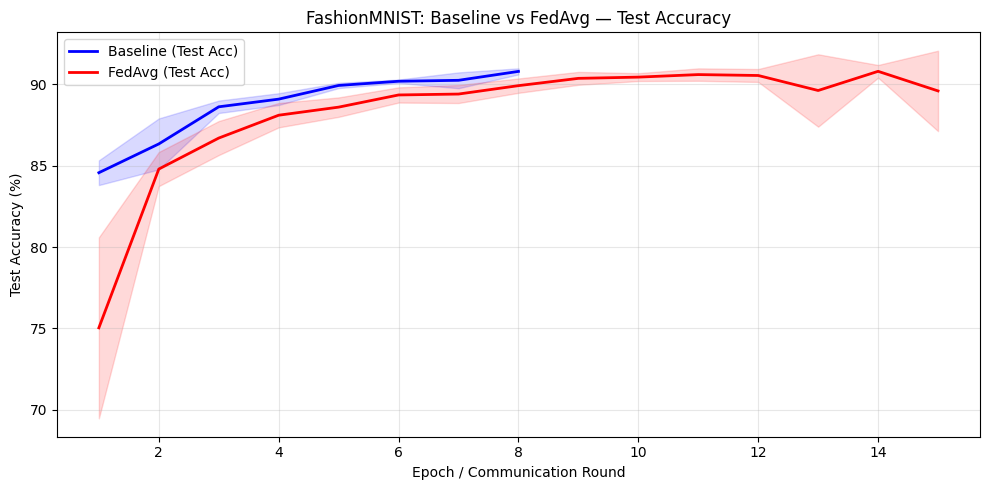

In [14]:
# Comparison utility (keeps same interface semantics)

def compare_results(baseline_test_acc, fedavg_test_acc_list, fedavg_val_acc_list, dataset_name):
    baseline_final = baseline_test_acc[:, -1]
    stacked_fed_test = np.array(fedavg_test_acc_list)
    stacked_fed_val = np.array(fedavg_val_acc_list)
    fed_final_test = stacked_fed_test[:, -1]
    fed_final_val = stacked_fed_val[:, -1]

    print('\n' + '='*60)
    print(f'Comparison: {dataset_name}')
    print('='*60)
    print(f'{'Method':<25} {'Mean Acc (%)':<15} {'Variance':<15}')
    print('-'*55)
    print(f"{'Baseline (Test)':<25} {baseline_final.mean():<15.2f} {baseline_final.var():<15.4f}")
    print(f"{'FedAvg (Validation)':<25} {fed_final_val.mean():<15.2f} {fed_final_val.var():<15.4f}")
    print(f"{'FedAvg (Test)':<25} {fed_final_test.mean():<15.2f} {fed_final_test.var():<15.4f}")
    print(f"{'Gap (Test)':<25} {fed_final_test.mean() - baseline_final.mean():<+15.2f}")

    # Combined visual
    fig, ax = plt.subplots(figsize=(10, 5))
    epochs = range(1, baseline_test_acc.shape[1] + 1)
    mean_base = baseline_test_acc.mean(axis=0)
    std_base = baseline_test_acc.std(axis=0)
    ax.plot(epochs, mean_base, 'b-', lw=2, label='Baseline (Test Acc)')
    ax.fill_between(epochs, mean_base - std_base, mean_base + std_base, alpha=0.15, color='blue')

    num_rounds = stacked_fed_test.shape[1]
    rounds = range(1, num_rounds + 1)
    mean_fed = stacked_fed_test.mean(axis=0)
    std_fed = stacked_fed_test.std(axis=0)
    ax.plot(rounds, mean_fed, 'r-', lw=2, label='FedAvg (Test Acc)')
    ax.fill_between(rounds, mean_fed - std_fed, mean_fed + std_fed, alpha=0.15, color='red')

    ax.set_xlabel('Epoch / Communication Round')
    ax.set_ylabel('Test Accuracy (%)')
    ax.set_title(f'{dataset_name}: Baseline vs FedAvg — Test Accuracy')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


compare_results(q1_test_acc, q2_test_acc, q2_val_acc, 'FashionMNIST')

Q3a: Baseline Centralized Training - CIFAR-10
  Run 1/5, Epoch 1/8: Train Acc: 38.43%, Test Acc: 50.46%
  Run 1/5, Epoch 2/8: Train Acc: 56.25%, Test Acc: 61.04%
  Run 1/5, Epoch 3/8: Train Acc: 63.78%, Test Acc: 64.05%
  Run 1/5, Epoch 4/8: Train Acc: 68.45%, Test Acc: 67.81%
  Run 1/5, Epoch 5/8: Train Acc: 72.18%, Test Acc: 71.11%
  Run 1/5, Epoch 6/8: Train Acc: 75.56%, Test Acc: 69.83%
  Run 1/5, Epoch 7/8: Train Acc: 78.18%, Test Acc: 72.82%
  Run 1/5, Epoch 8/8: Train Acc: 81.24%, Test Acc: 72.63%
--- Run 1 Final: Train 81.24%, Test 72.63% ---

  Run 2/5, Epoch 1/8: Train Acc: 37.84%, Test Acc: 48.74%
  Run 2/5, Epoch 2/8: Train Acc: 55.33%, Test Acc: 59.15%
  Run 2/5, Epoch 3/8: Train Acc: 62.95%, Test Acc: 65.31%
  Run 2/5, Epoch 4/8: Train Acc: 67.89%, Test Acc: 65.83%
  Run 2/5, Epoch 5/8: Train Acc: 71.84%, Test Acc: 70.50%
  Run 2/5, Epoch 6/8: Train Acc: 75.17%, Test Acc: 70.07%
  Run 2/5, Epoch 7/8: Train Acc: 77.99%, Test Acc: 71.91%
  Run 2/5, Epoch 8/8: Train Acc: 80.

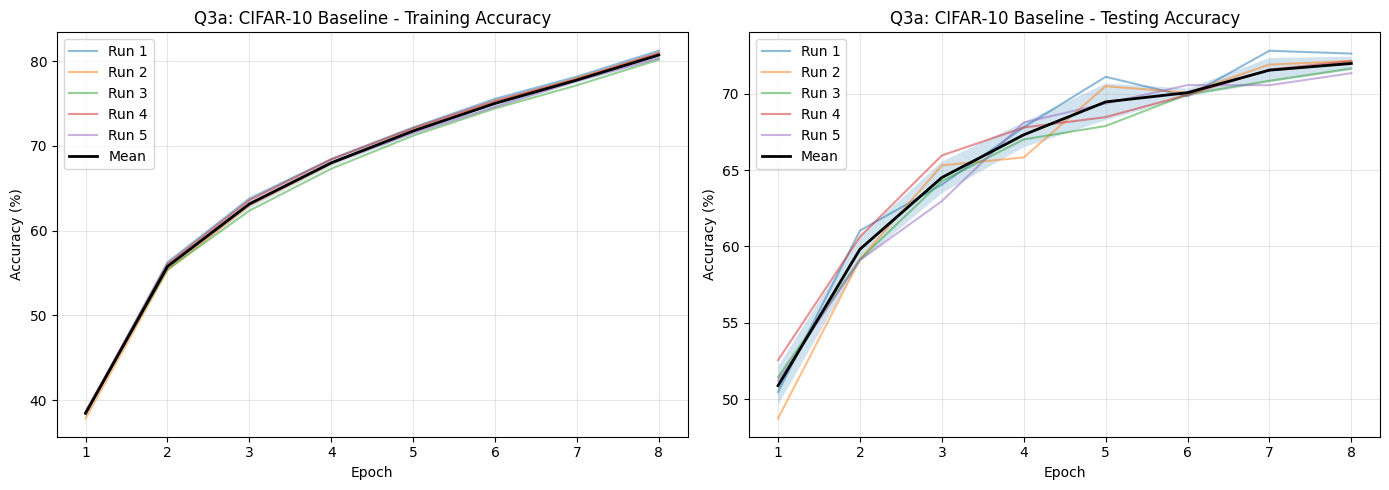


Q3a: CIFAR-10 Baseline - Final Converged Model Results (over 5 runs):
  Training Accuracy:  Mean = 80.73%, Variance = 0.1590
  Testing  Accuracy:  Mean = 71.99%, Variance = 0.1952


In [15]:
print('='*60)
print('Q3a: Baseline Centralized Training - CIFAR-10')
print('='*60)

q3a_train_acc, q3a_test_acc = baseline_training(
    cifar_full, cifar_test, SmallCNN_CIFAR,
    runs=5, epochs=8, batch_size=128, lr=0.01, device=device
)

draw_baseline_curves(q3a_train_acc, q3a_test_acc, 'Q3a: CIFAR-10 Baseline')

Q3b: FedAvg - CIFAR-10

--- FedAvg Run 1/5 ---
  Client data sizes: [11184, 1852, 16382, 4355, 11227]
  Round 1/10: Val: 49.20% | Test: 49.29% | Clients: [64.4%, 47.4%, 57.8%, 51.9%, 69.2%]
  Round 5/10: Val: 66.66% | Test: 67.69% | Clients: [94.8%, 91.7%, 95.7%, 91.5%, 96.1%]
  Round 10/10: Val: 66.84% | Test: 67.65% | Clients: [98.8%, 92.6%, 98.3%, 93.8%, 99.1%]
--- Run 1 Final: Val: 66.84%, Test: 67.65% ---

--- FedAvg Run 2/5 ---
  Client data sizes: [9017, 5268, 12635, 7713, 10367]
  Round 1/10: Val: 36.50% | Test: 36.86% | Clients: [60.7%, 61.5%, 68.0%, 57.1%, 68.5%]
  Round 5/10: Val: 66.48% | Test: 66.56% | Clients: [93.4%, 93.0%, 94.5%, 89.4%, 95.4%]
  Round 10/10: Val: 68.00% | Test: 68.25% | Clients: [98.3%, 96.6%, 99.2%, 96.8%, 98.6%]
--- Run 2 Final: Val: 68.00%, Test: 68.25% ---

--- FedAvg Run 3/5 ---
  Client data sizes: [10123, 4879, 11620, 7206, 11172]
  Round 1/10: Val: 50.44% | Test: 51.17% | Clients: [54.6%, 55.9%, 55.8%, 61.1%, 62.4%]
  Round 5/10: Val: 69.44% | T

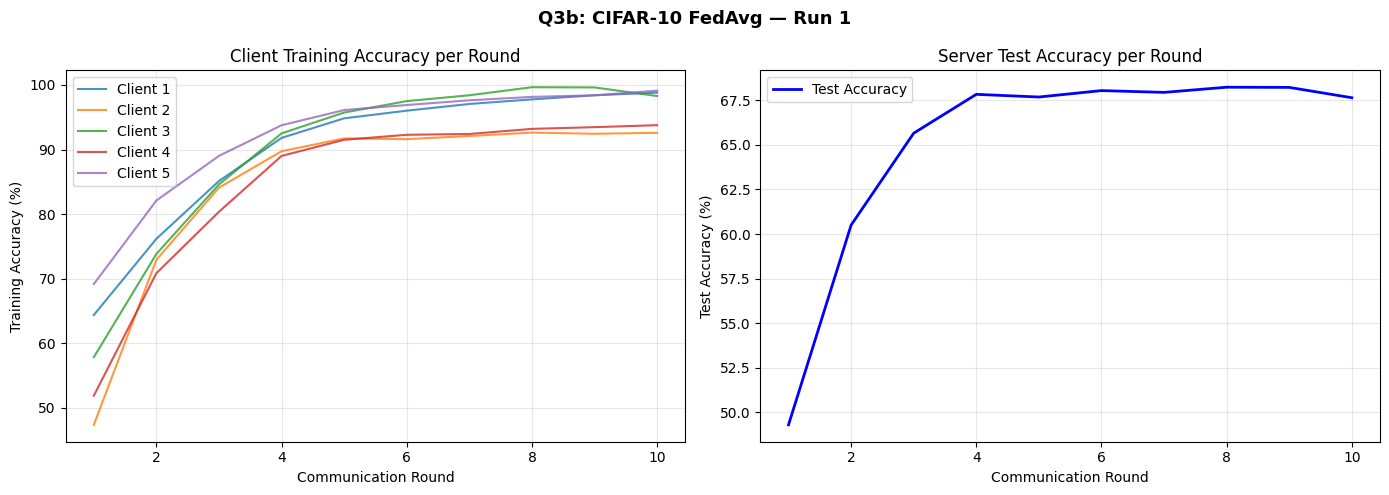

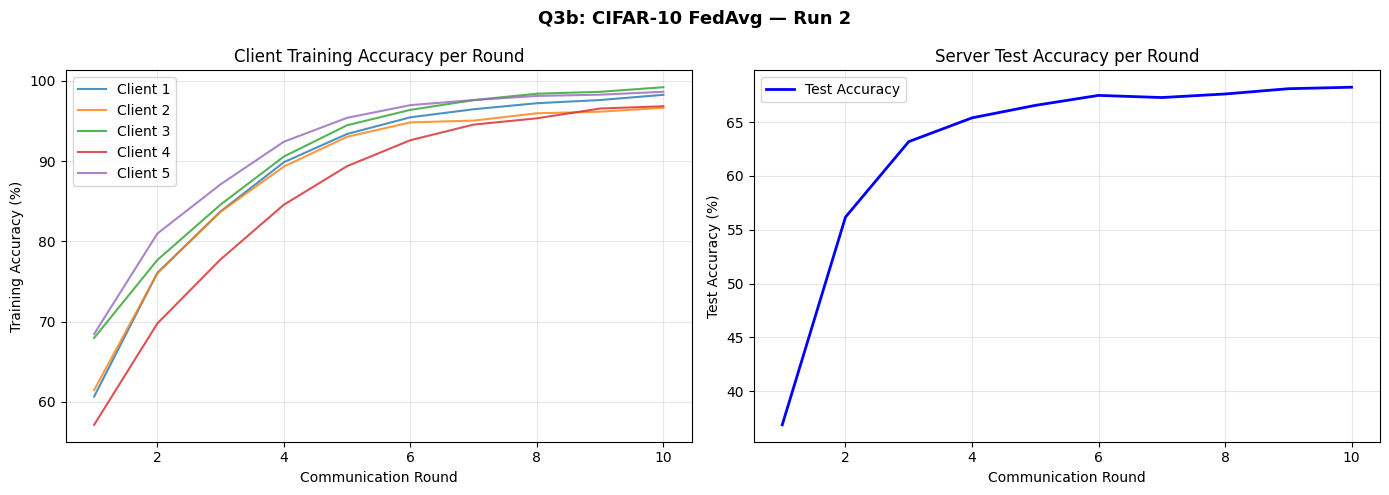

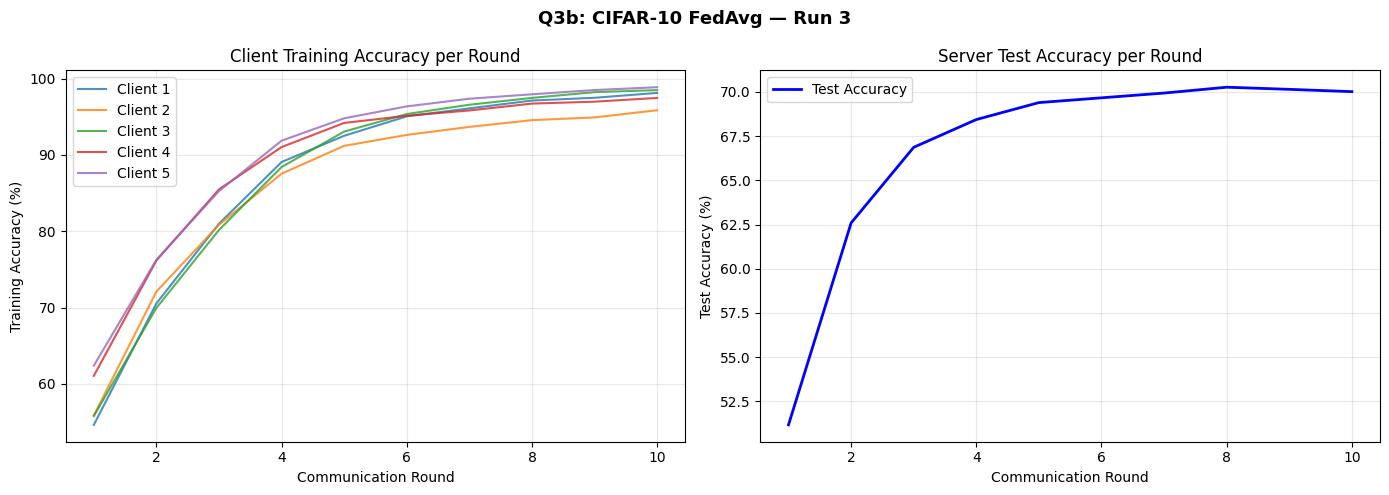

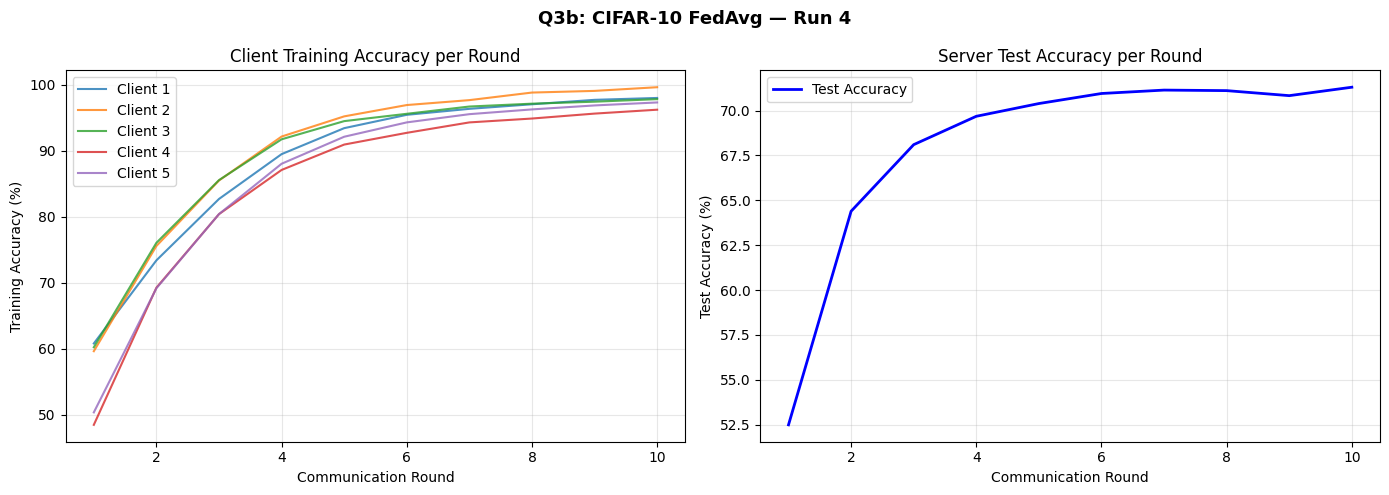

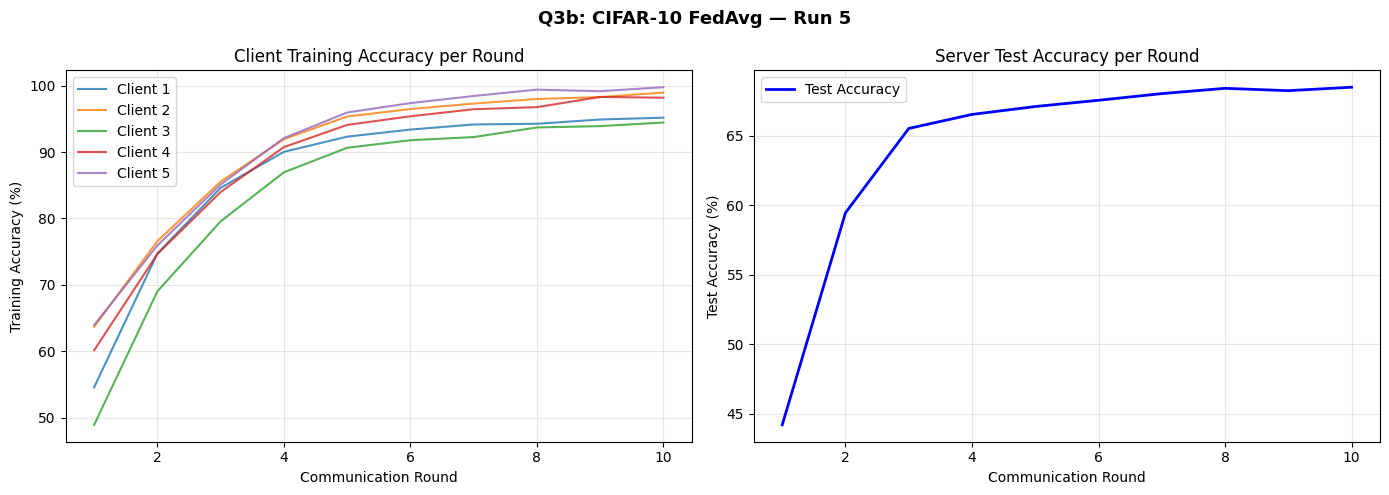

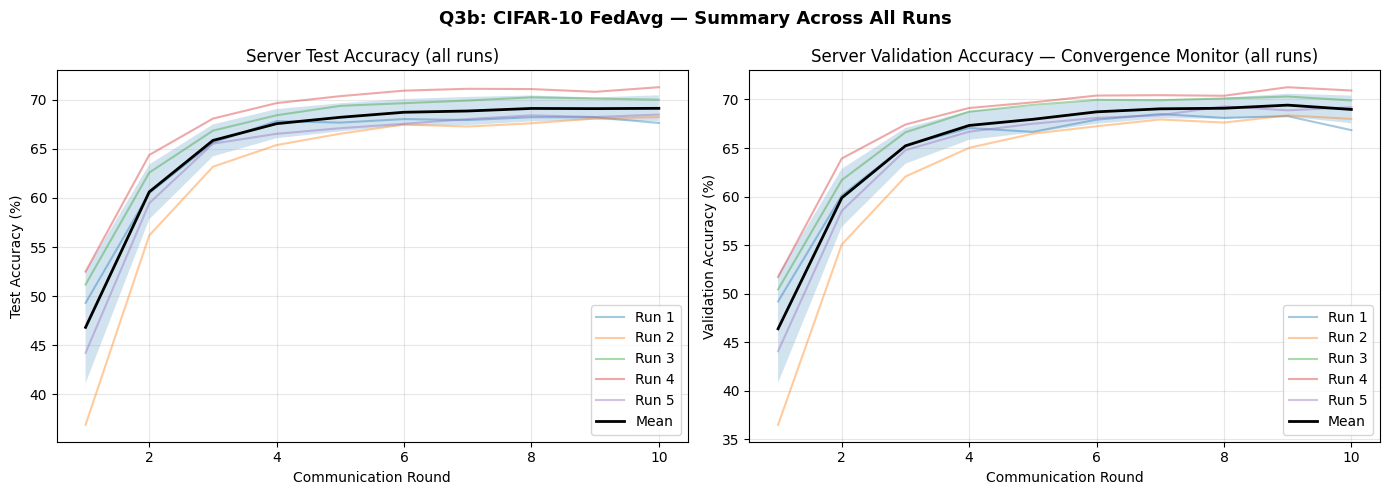


Q3b: CIFAR-10 FedAvg - Final Converged Model Results (over 5 runs):
  Validation Accuracy: Mean = 68.97%, Variance = 2.0396
  Test Accuracy:       Mean = 69.15%, Variance = 1.7698


In [16]:
print('='*60)
print('Q3b: FedAvg - CIFAR-10')
print('='*60)

q3b_client_acc, q3b_val_acc, q3b_test_acc = federated_averaging(
    cifar_train, cifar_val, cifar_test, SmallCNN_CIFAR,
    num_clients=5, runs=5, rounds=10, local_epochs=5,
    batch_size=64, lr=0.01, patience=4, device=device
)

draw_fedavg_curves(
    q3b_client_acc, q3b_test_acc, q3b_val_acc,
    'Q3b: CIFAR-10 FedAvg', num_clients=5
)


Comparison: CIFAR-10
Method                    Mean Acc (%)    Variance       
-------------------------------------------------------
Baseline (Test)           71.99           0.1952         
FedAvg (Validation)       68.97           2.0396         
FedAvg (Test)             69.15           1.7698         
Gap (Test)                -2.84          


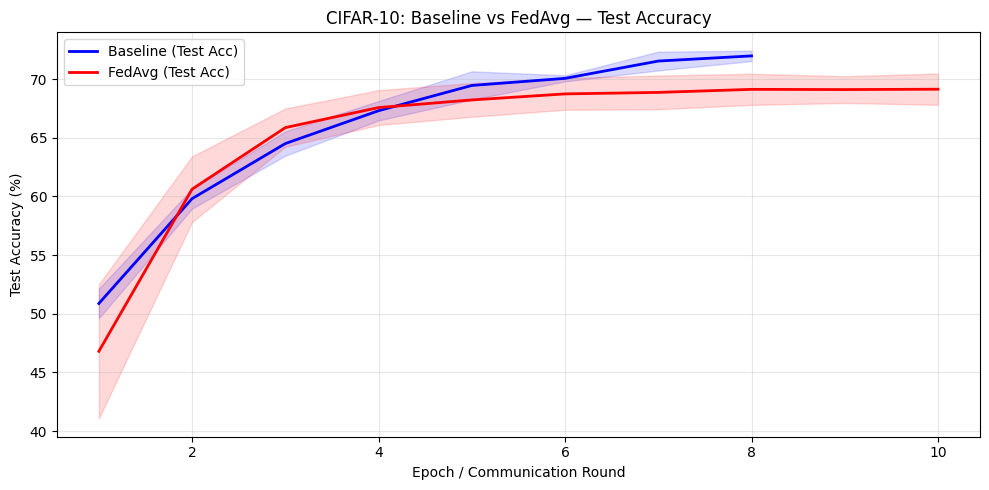

In [20]:
# Comparison utility (keeps same interface semantics)

def compare_results(baseline_test_acc, fedavg_test_acc_list, fedavg_val_acc_list, dataset_name):
    baseline_final = baseline_test_acc[:, -1]
    stacked_fed_test = np.array(fedavg_test_acc_list)
    stacked_fed_val = np.array(fedavg_val_acc_list)
    fed_final_test = stacked_fed_test[:, -1]
    fed_final_val = stacked_fed_val[:, -1]

    print('\n' + '='*60)
    print(f'Comparison: {dataset_name}')
    print('='*60)
    print(f'{'Method':<25} {'Mean Acc (%)':<15} {'Variance':<15}')
    print('-'*55)
    print(f"{'Baseline (Test)':<25} {baseline_final.mean():<15.2f} {baseline_final.var():<15.4f}")
    print(f"{'FedAvg (Validation)':<25} {fed_final_val.mean():<15.2f} {fed_final_val.var():<15.4f}")
    print(f"{'FedAvg (Test)':<25} {fed_final_test.mean():<15.2f} {fed_final_test.var():<15.4f}")
    print(f"{'Gap (Test)':<25} {fed_final_test.mean() - baseline_final.mean():<+15.2f}")

    # Combined visual
    fig, ax = plt.subplots(figsize=(10, 5))
    epochs = range(1, baseline_test_acc.shape[1] + 1)
    mean_base = baseline_test_acc.mean(axis=0)
    std_base = baseline_test_acc.std(axis=0)
    ax.plot(epochs, mean_base, 'b-', lw=2, label='Baseline (Test Acc)')
    ax.fill_between(epochs, mean_base - std_base, mean_base + std_base, alpha=0.15, color='blue')

    num_rounds = stacked_fed_test.shape[1]
    rounds = range(1, num_rounds + 1)
    mean_fed = stacked_fed_test.mean(axis=0)
    std_fed = stacked_fed_test.std(axis=0)
    ax.plot(rounds, mean_fed, 'r-', lw=2, label='FedAvg (Test Acc)')
    ax.fill_between(rounds, mean_fed - std_fed, mean_fed + std_fed, alpha=0.15, color='red')

    ax.set_xlabel('Epoch / Communication Round')
    ax.set_ylabel('Test Accuracy (%)')
    ax.set_title(f'{dataset_name}: Baseline vs FedAvg — Test Accuracy')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# CIFAR-10 comparison
compare_results(q3a_test_acc, q3b_test_acc, q3b_val_acc, 'CIFAR-10')


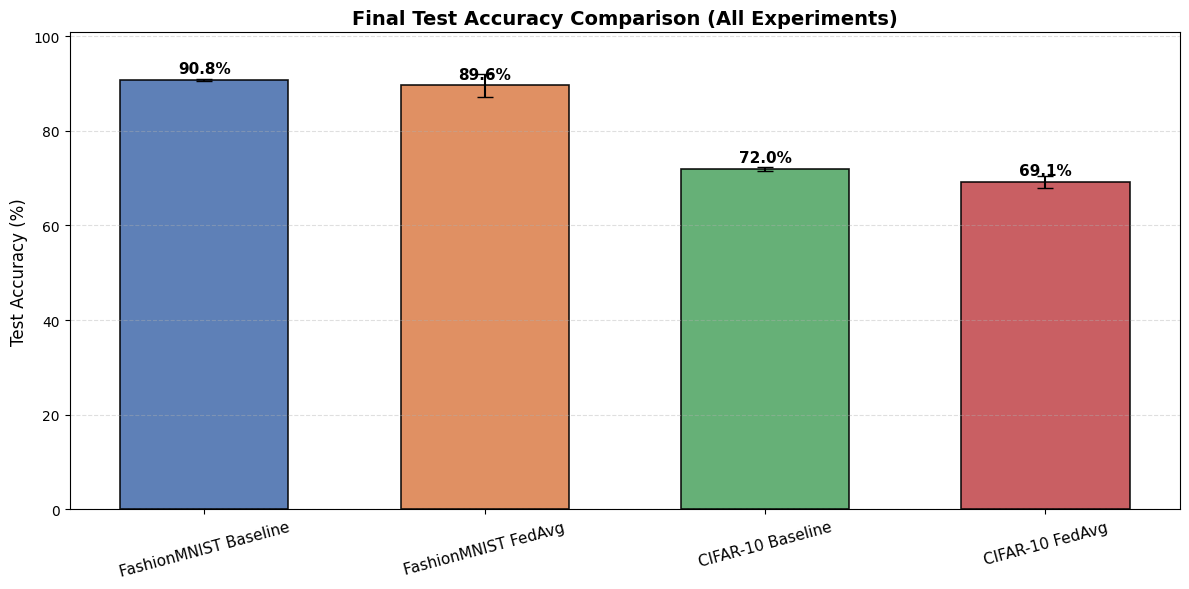

In [19]:
# Bar chart comparison (enhanced style)
fig, ax = plt.subplots(figsize=(12, 6))

names = list(results.keys())
means = [v.mean() for v in results.values()]
stds = [v.std() for v in results.values()]

# Better colors
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

# Bar width
bars = ax.bar(
    names,
    means,
    width=0.6,
    yerr=stds,
    capsize=6,
    color=colors,
    edgecolor='black',
    linewidth=1.2,
    alpha=0.9
)

# Axis labels and title
ax.set_ylabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Final Test Accuracy Comparison (All Experiments)', fontsize=14, fontweight='bold')

# Grid style
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Improve tick labels
plt.xticks(rotation=15, fontsize=11)

# Value labels on bars
for bar, mean in zip(bars, means):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.8,
        f'{mean:.1f}%',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

# Slight padding at top
ax.set_ylim(0, max(means) + 10)

plt.tight_layout()
plt.show()